## Retention

Это небольшой ноутбук с реализацией расчетов разных типов ретеншена. Формулы и подходы хорошо описаны в следующих материалах: [статья 1](https://gopractice.ru/product/retention/), [статья 2](https://gopractice.ru/product/nday-retention-rollling-retention/). Здесь только код и мысли на тему решения :) 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df_orders = pd.read_excel('data_for_retention.xlsx', sheet_name = 'orders')
df_registrations = pd.read_excel('data_for_retention.xlsx', sheet_name = 'registrations')

In [3]:
df_orders['created_at'] = pd.to_datetime(df_orders['created_at'])
df_registrations['created_at'] = pd.to_datetime(df_registrations['created_at'])

In [4]:
df_orders.head()

,order_id,user_id,created_at,order_amount,discount
0,63da3cbf2d95d6499efa4191,449e112fc29c236d8a722173d1f45be6,2023-02-01,107.90,0.0
1,63e47bec3a63d2afb19a2190,5738b0aec9a5c0c8bb3acaf7e906076b,2023-02-09,39.00,0.0
2,63e9b561db223821d7f89a38,4816c12497b24bb139b0e244bd08428f,2023-02-13,14.50,0.0
3,63e8b439f59f5773ec2bf4d2,f5f25032a84e3092530b69cbcec7f046,2023-02-12,27.00,0.0
4,63e9c1bef59f5773ec2bfd45,487fbf3c3c120897bb6350a92a3dfc5d,2023-02-13,80.45,0.0


In [5]:
df_registrations.head()

,user_id,created_at
0,ce26e83c606eac7f793c68d55637e719,2023-01-30
1,216fa9b712f91d2859e56f47e0fa2aeb,2023-02-07
2,114032c7e47080f2a0e9dcb68a082fa7,2023-01-16
3,dc76b077bb1424f220c263623583f795,2022-12-25
4,64a6113f0602feb4b55d0f14e9c3e7d1,2022-12-05


Ретеншен можно рассчитывать от разных действий. Можно проверять активность пользователя (факт захода в приложение) со дня регистрации, а можно смотреть возвратность в целевое действие после того, как юзер совершил это действие первый раз.   

Подход выбирается в зависимости от типа продукта и решаемой в анализе задачи — для социальных сетей или игр подойдет любая активность, тогда как для типов продуктов, в которых есть явное целевое действие (покупка, заказ, поездка и т.д.), в качестве стартовой даты рассчета ретеншена часто используют дату, в которую юзер совершил свою первую покупку / заказ / поездку и т.д.

В данном ноутбуке мы работаем с данными сервиса доставки продуктов, поэтому за 0 день в расчете ретеншена используем дату первого заказа, а возвратностью считаем повторные заказы.

In [6]:
df_orders_w_reg = df_orders.merge(df_registrations.rename(columns={'created_at':'registration_date'}),
                                  on='user_id',
                                  how='left')

In [7]:
df_first_order_date = df_orders_w_reg[~df_orders_w_reg['registration_date'].isna()] \
    .groupby(['user_id', 'registration_date'], as_index=False) \
    .created_at.min().rename(columns={'created_at':'first_order_date'})

In [8]:
df_new_users_orders = df_orders.merge(df_first_order_date, on=['user_id'], how='inner')

### Day N Retention

Считаем долю пользователей, совершивших заказы на день N после первого заказа (день первого заказа считается нулевым).

Такой способ расчета подходит продуктам с высокой частотой использования — стриминговые сервисы, соц сети, игры, быстрая доставка FMCG товаров. Другими словами те, в которых целевым состоянием является ежедневное использование

In [9]:
df_new_users_orders['days_since_first'] = (df_new_users_orders['created_at'] - df_new_users_orders['first_order_date']).dt.days

Т.к. данных не очень много, будем агрегировать рассчитанные когорты по месяцам, но в зависимости от задачи данные можно смотреть в любых временных агрегациях (держа в голове, что когорты внутри периода могут вести себя по-разному).

In [10]:
df_new_users_orders['month'] = df_new_users_orders['first_order_date'].dt.to_period('M').dt.to_timestamp()

In [11]:
df_retained_daily = df_new_users_orders.groupby(['month', 'days_since_first'], as_index=False) \
    .agg(retained_users=('user_id', 'nunique')).sort_values(by=['month', 'days_since_first'])

In [12]:
df_retention_day_n = df_retained_daily \
    .merge(df_retained_daily[df_retained_daily['days_since_first'] == 0][['month', 'retained_users']] \
    .rename(columns={'retained_users':'base'}), on=['month'], how='left')

In [13]:
df_retention_day_n['retention_rate'] = df_retention_day_n.retained_users / df_retention_day_n.base

In [14]:
df_retention_day_n_pivoted = df_retention_day_n[df_retention_day_n['days_since_first'].isin([7, 14, 30])] \
    .pivot(index='month', columns='days_since_first', values='retention_rate') \
    .rename(columns=lambda x: f'D_{int(x)}') \
    .reset_index() \
    .rename_axis(index=None, columns=None) \
    .sort_values('month')

In [15]:
def get_retention_plot(df, x,  y_list, time):
    plt.figure(figsize=(12,6))
    colors = ['green', 'blue', 'orange']
    
    for i in range(len(y_list)):
        plt.plot(df[x].astype('str'), df[y_list[i]], label=f'{y_list[i]}', color=colors[i])

    plt.title(f'Retention {time}')
    plt.xlabel('Cohort Date')
    plt.xticks(rotation=45)
    plt.ylabel('Retention Rate')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    
    
    return plt.show()

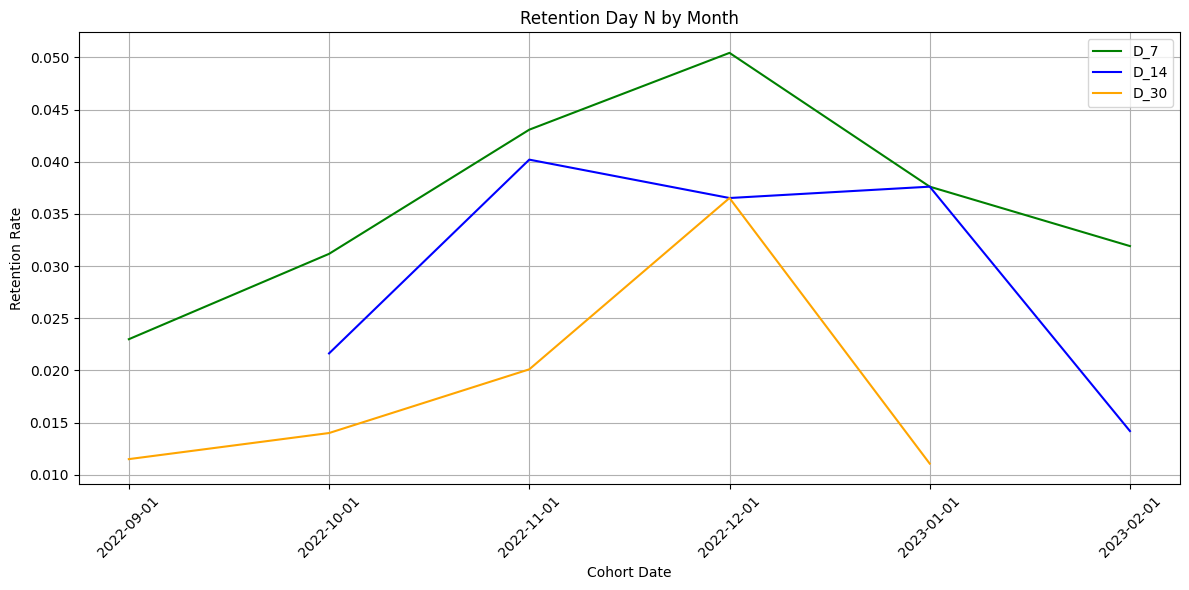

In [16]:
get_retention_plot(df_retention_day_n_pivoted, 'month',  ['D_7', 'D_14', 'D_30'], 'Day N by Month')

На графике выше — Day 7, Day 14 и Day 30 Retention для когорт разных месяцев.

Day 30 Retention для февраля 2023 еще не существует, т.к. не успело пройти 30 дней с момента первого действия пользователей когорты (последняя дата в df 2023-02-22). 

А для сентября 2022 никто из новых пользователей не совершил повторный заказ на 14-й день.

#### Retention Curve

Еще один полезный способ визуализировать удержание. По оси X располагаются дни, прошедшие с момента первого действия. По оси Y — доля удержанных пользователей к этому дню. График позволяет понять, через какое время ретеншен выходит на плато, то есть пользователи привыкают использовать продукт и остаются с нами.

Вы можете построить кривую как для когорты конкретного дня, так и агрегировать для любого периода — недели, месяца, квартала и т.д. В примере я работаю со всем датасетом сразу, чтобы получить бОльший объем данных для визуализации.

In [17]:
df_retention_grouped = df_retention_day_n.groupby(['days_since_first'], as_index=False) \
    .agg(retained_users=('retained_users', 'sum'),
         base=('base', 'sum'))

df_retention_grouped['retention_rate'] = df_retention_grouped.retained_users / df_retention_grouped.base


df_retention_grouped_30 = df_retention_grouped[df_retention_grouped['days_since_first'] <= 30]

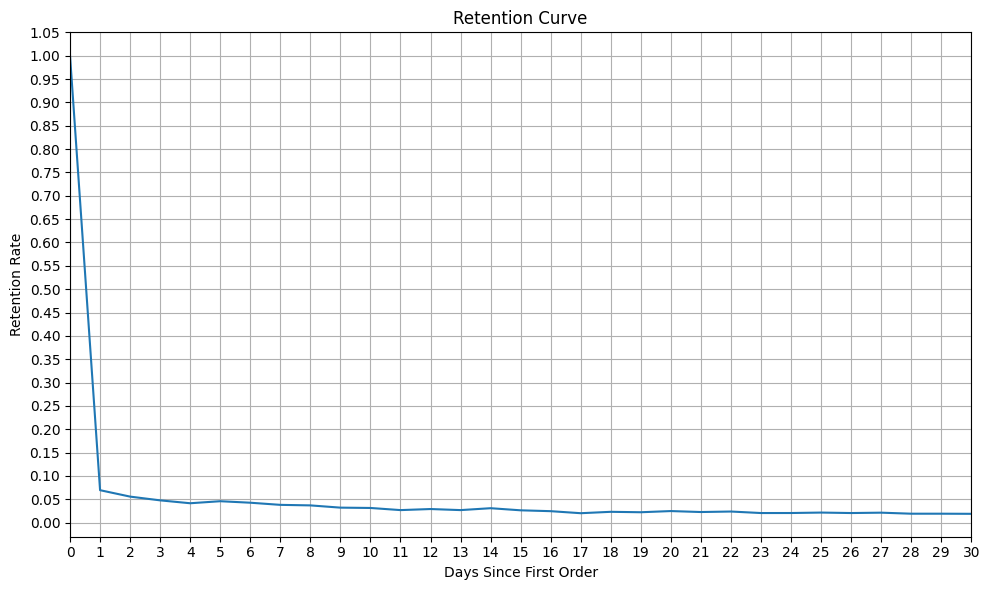

In [18]:
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(df_retention_grouped_30['days_since_first'], df_retention_grouped_30['retention_rate'])

ax.set_title('Retention Curve')
ax.set_xlabel('Days Since First Order')
ax.set_ylabel('Retention Rate')
ax.grid()

ax.set_yticks(np.arange(0, 1.1, 0.05))
ax.set_xticks(np.arange(0, 31, 1))
ax.margins(x=0)
plt.tight_layout()
plt.show()

#### Period N Retention 

Для подуктов, которые не подразумевают ежедневное использование, Day N Retention оказывается бесполезным. Нам сложно выделить конкретную дату, в которую юзер повзаимодействует с нами повторно, а значит, выбирая точечные значения, мы можем сильно занизить понимание реальной ценноси продукта для пользователя, т.к. заметная часть из них могла вернуться на пару дней раньше или позже.

В таком случае можно считать возвратность в течение недель или даже месяцев. В нашем примере Day N ретеншен имеет очень низкие значения, вероятно сервис ипользуют реже. Попробуем сделать расчет Week N Retention.

In [19]:
df_new_users_orders['weeks_since_first'] = np.where(df_new_users_orders['days_since_first'] == 0, 
                                                    0, ((df_new_users_orders['days_since_first'] - 1) // 7) + 1)

In [20]:
df_retained_by_week = df_new_users_orders.groupby(['month', 'weeks_since_first'], as_index=False) \
    .agg(retained_users=('user_id', 'nunique')).sort_values(by=['month', 'weeks_since_first'])

In [21]:
df_retention_week_n = df_retained_by_week \
    .merge(df_retained_by_week[df_retained_by_week['weeks_since_first'] == 0][['month', 'retained_users']] \
    .rename(columns={'retained_users':'base'}), on=['month'], how='left')

In [22]:
df_retention_week_n['retention_rate'] = df_retention_week_n.retained_users / df_retention_week_n.base

In [23]:
df_retention_week_n_pivoted = df_retention_week_n[df_retention_week_n['weeks_since_first'].isin([1, 2, 4])] \
    .pivot(index='month', columns='weeks_since_first', values='retention_rate') \
    .rename(columns=lambda x: f'W_{int(x)}') \
    .reset_index() \
    .rename_axis(index=None, columns=None) \
    .sort_values('month')

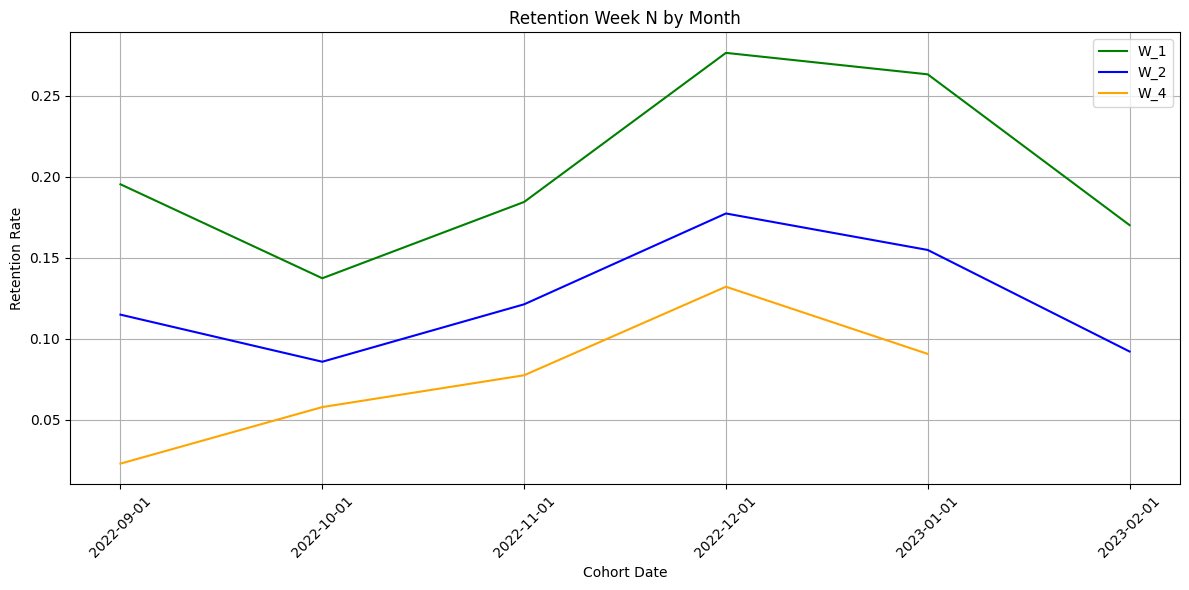

In [24]:
get_retention_plot(df_retention_week_n_pivoted, 'month',  ['W_1', 'W_2', 'W_4'], 'Week N by Month')

При недельном расчете ретеншена видим, что фактическое удержание пользователей оказалось выше, чем при дневной оценке. 

### Rolling Retention

Еще один способ подсчета ретеншена — скользящий, в котором мы учитываем действия, совершенные пользователем не только в выбранный день / период, но и во все даты после него. Так, в Day 7 Rolling Retention попадут пользователи, сделавшие заказ не только на 7 день, но и в любой другой день после.

При подготовке аналитики важно подчеркивать подход, который вы решили использовать, т.к. скользящая формула завышает значения по сравнению с фиксированным окном. При этом для низкочастотных продуктов Rolling Retention может быть более подходящим вариантом. Например, магазинам крупной бытовой техники сложно определить даже месяц потенциального повторного возврата, но отслеживать удержание все равно нужно.

Ниже расчет Day N Rolling Retention.

In [25]:
df_new_users_max_diff = df_new_users_orders.groupby(['month', 'first_order_date', 'user_id'], as_index=False) \
    .days_since_first.max()

In [26]:
df_retained_by_max_diff = df_new_users_max_diff.groupby(['month', 'days_since_first'], as_index=False) \
    .agg(retained_users=('user_id', 'nunique'))

In [27]:
df_retained_by_max_diff_pivoted = df_retained_by_max_diff \
    .pivot(index='month', columns='days_since_first', values='retained_users') \
    .fillna(0).astype(int)

df_retained_by_max_diff_pivoted.head()

days_since_first,0,1,2,3,4,5,6,7,8,9,...,129,130,131,132,133,137,141,142,143,144
month,,,,,,,,,,,,,,,,,,,,,
2022-09-01,62,4,2,1,1,1,0,0,0,3,...,0,0,0,0,0,0,1,0,1,0
2022-10-01,1264,15,13,13,6,7,10,4,5,6,...,1,1,1,2,2,1,0,1,0,1
2022-11-01,1012,19,12,15,5,19,12,10,4,7,...,0,0,0,0,0,0,0,0,0,0
2022-12-01,323,20,8,11,7,10,4,7,3,5,...,0,0,0,0,0,0,0,0,0,0
2023-01-01,288,15,9,6,7,8,7,4,4,1,...,0,0,0,0,0,0,0,0,0,0


In [33]:
df_retained_rolling = df_retained_by_max_diff_pivoted.iloc[:, ::-1].cumsum(axis=1).iloc[:, ::-1]

df_retained_rolling.head()

days_since_first,0,1,2,3,4,5,6,7,8,9,...,129,130,131,132,133,137,141,142,143,144
month,,,,,,,,,,,,,,,,,,,,,
2022-09-01,87,25,21,19,18,17,16,16,16,16,...,2,2,2,2,2,2,2,1,1,0
2022-10-01,1572,308,293,280,267,261,254,244,240,235,...,10,9,8,7,5,3,2,2,1,1
2022-11-01,1393,381,362,350,335,330,311,299,289,285,...,0,0,0,0,0,0,0,0,0,0
2022-12-01,575,252,232,224,213,206,196,192,185,182,...,0,0,0,0,0,0,0,0,0,0
2023-01-01,452,164,149,140,134,127,119,112,108,104,...,0,0,0,0,0,0,0,0,0,0


In [34]:
df_retained_rolling_30 = df_retained_rolling.loc[:, 0:30]

In [35]:
df_retention_rolling_30 = df_retained_rolling_30.div(df_retained_rolling_30[0], axis=0)

In [36]:
df_retention_rolling_30 = df_retention_rolling_30 \
    .rename(columns=lambda x: f'D_{int(x)}_rolling') \
    .reset_index() \
    .rename_axis(index=None, columns=None) \
    .sort_values('month')

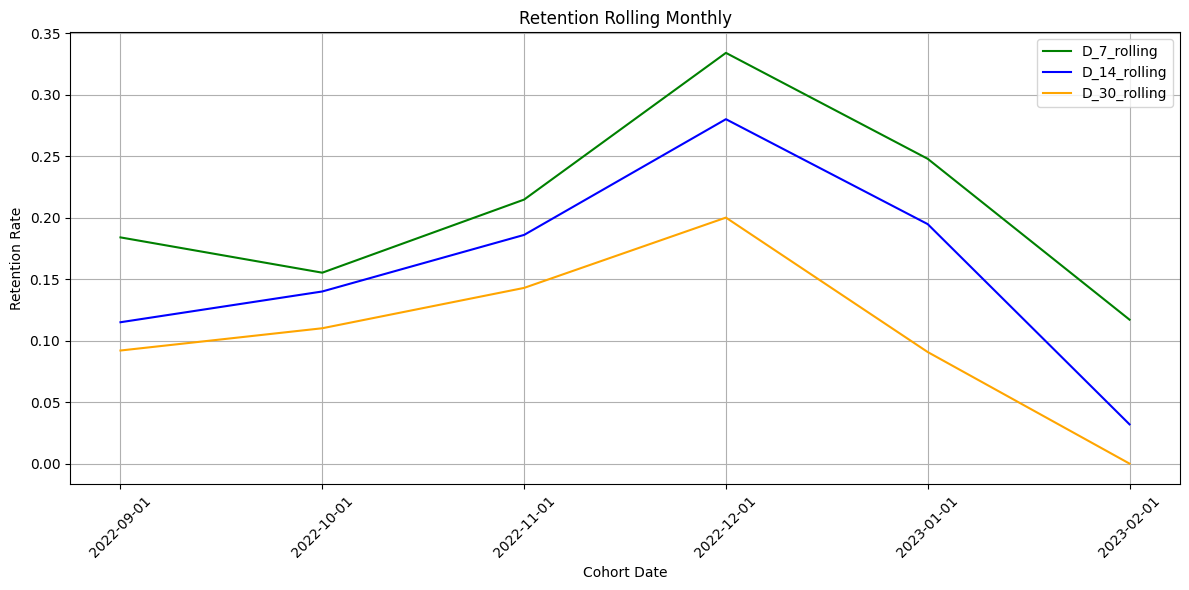

In [37]:
get_retention_plot(df_retention_rolling_30, 'month',  ['D_7_rolling', 'D_14_rolling', 'D_30_rolling'], 'Rolling Monthly')

Перед расчетом ретеншена обсудите с командой, как изменятся ваши действия при разных значениях этой метрики. Это должно помочь выбрать наиболее подходящий подход из вышеперечисленных. 